In [2]:
%load_ext autoreload

In [3]:
%autoreload 2

In [4]:
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler


data = load_iris()
X = data.data
y = data.target

scaler = StandardScaler()
X = scaler.fit_transform(X)

In [5]:
from gmm import GMM
gmm = GMM(n_components=3, max_iter=100)
gmm.initialize(X, 'kmeans')

In [6]:
gmm.fit(X)
labels = gmm.predict(X)

Iteration 1, log-likelihood: -318.497085
Iteration 2, log-likelihood: -316.244658
Iteration 3, log-likelihood: -315.642378
Iteration 4, log-likelihood: -314.423963
Iteration 5, log-likelihood: -312.878268
Iteration 6, log-likelihood: -310.098491
Iteration 7, log-likelihood: -305.636459
Iteration 8, log-likelihood: -300.311691
Iteration 9, log-likelihood: -297.807296
Iteration 10, log-likelihood: -296.722683
Iteration 11, log-likelihood: -295.846273
Iteration 12, log-likelihood: -294.939029
Iteration 13, log-likelihood: -294.054040
Iteration 14, log-likelihood: -293.214664
Iteration 15, log-likelihood: -292.418888
Iteration 16, log-likelihood: -291.624131
Iteration 17, log-likelihood: -291.037017
Iteration 18, log-likelihood: -290.737727
Iteration 19, log-likelihood: -290.608289
Iteration 20, log-likelihood: -290.558210
Iteration 21, log-likelihood: -290.540349
Iteration 22, log-likelihood: -290.534204
Iteration 23, log-likelihood: -290.532119
Iteration 24, log-likelihood: -290.531416
I

In [15]:
my_ll = gmm.compute_log_likelihood(X)
my_ll

np.float64(-290.5311012462124)

In [12]:
from sklearn.mixture import GaussianMixture

sk_gmm = GaussianMixture(n_components=3)

sk_gmm.fit(X)

print(sk_gmm.score(X) * len(X))

-290.54277440458924


# Гауссовы компоненты

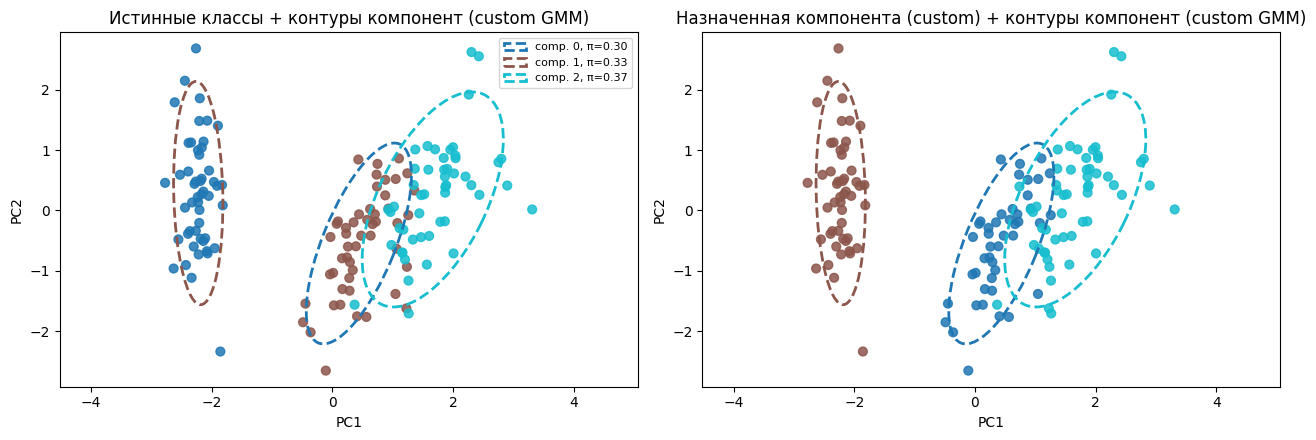

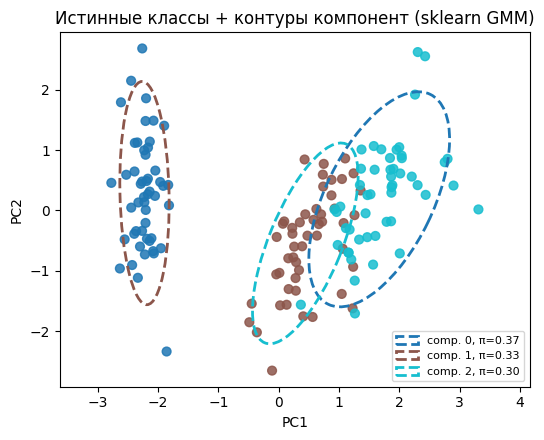

In [13]:
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
from sklearn.decomposition import PCA
import numpy as np

SEED = 42


def add_component_ellipses(ax, component_weights, means, cov, pca, nstd: float = 2.0, colors=None):
    """Эллипсы ковариаций компонент в 2D-пространстве PCA."""
    V = pca.components_
    xm = pca.mean_
    if colors is None:
        colors = plt.cm.tab10(np.linspace(0, 1, component_weights.shape[0]))
    for k in range(component_weights.shape[0]):
        mu_z = (means[k] - xm) @ V.T
        cov_z = V @ cov[k] @ V.T
        vals, vecs = np.linalg.eigh(cov_z)
        vals = np.maximum(vals, 1e-9)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        w, h = 2 * nstd * np.sqrt(vals)
        ell = Ellipse(
            xy=mu_z,
            width=w,
            height=h,
            angle=theta,
            edgecolor=colors[k],
            facecolor="none",
            linewidth=2,
            linestyle="--",
            label=f"comp. {k}, π={component_weights[k]:.2f}",
        )
        ax.add_patch(ell)


pca = PCA(n_components=2, random_state=SEED)
Z = pca.fit_transform(X)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

ax[0].scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=40, alpha=0.85)
ax[0].set_title("Истинные классы + контуры компонент (custom GMM)")
add_component_ellipses(ax[0], gmm.component_weights, gmm.means, gmm.cov, pca)
ax[0].legend(loc="best", fontsize=8)
ax[0].set_xlabel("PC1")
ax[0].set_ylabel("PC2")
ax[0].set_aspect("equal", adjustable="datalim")

ax[1].scatter(Z[:, 0], Z[:, 1], c=labels, cmap="tab10", s=40, alpha=0.85)
ax[1].set_title("Назначенная компонента (custom) + контуры компонент (custom GMM)")
add_component_ellipses(ax[1], gmm.component_weights, gmm.means, gmm.cov, pca)
ax[1].set_xlabel("PC1")
ax[1].set_ylabel("PC2")
ax[1].set_aspect("equal", adjustable="datalim")

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(1, 1, figsize=(5.5, 4.5))
ax2.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=40, alpha=0.85)
add_component_ellipses(ax2, sk_gmm.weights_, sk_gmm.means_, sk_gmm.covariances_, pca)
ax2.set_title("Истинные классы + контуры компонент (sklearn GMM)")
ax2.legend(loc="best", fontsize=8)
ax2.set_xlabel("PC1")
ax2.set_ylabel("PC2")
ax2.set_aspect("equal", adjustable="datalim")
plt.tight_layout()
plt.show()
